# La variable aleatoria asociada al evento $S_n$


## Introducción a los diccionarios en python


Un diccionario en Python es un objeto que se crea a partir de algo que se llama "llave" y nos arroja "valores".

$$ \{\text{key (llave)}: \text{valores}\}$$


In [2]:
dic1 = {
    "Claudia": ["Masha","Snow"],
    "Calificaciones": [10,9, 8, 9.5],
    "Documento": ["G2436778"]
}

dic1

{'Claudia': ['Masha', 'Snow'],
 'Calificaciones': [10, 9, 8, 9.5],
 'Documento': ['G2436778']}

In [6]:
# Para acceder solo a las calificacioes
calif = dic1["Calificaciones"]
calif

[10, 9, 8, 9.5]

In [7]:
dic1["Calificaciones"][3]

9.5

Otra forma de crear diccionarios es usando `dict()` de la forma `(llave,valor)`


In [ ]:
dict([
    ("Claudia", ["Masha","Snow"]),
    ("Calificaciones", [10,9, 8, 9.5]),
    ("Documento", ["G2436778"])
])

{'Claudia': ['Masha', 'Snow'],
 'Calificaciones': [10, 9, 8, 9.5],
 'Documento': ['G2436778']}

In [12]:
import itertools as it
from itertools import product

In [ ]:
Omega = set(product([1,2,3,4,5,6], repeat=2))

In [26]:
# Vamos a crear un diccionario para S_n
Sn = {(i,j):i+j for i,j in Omega}
# Asociamos a cada par de números la suma de ambos números
#Sn

In [27]:
# Vamos a agrupar combinaciones por suma (mismo resultado)

from collections import defaultdict

In [28]:
dSn = defaultdict(set)

In [34]:
#Vamos a recorrer los elementos de Sn
for i,j in Sn.items(): # para recorrer simultaneamente las llaves y los valores
    dSn[j].add(i) # i es la llave (a,b) y j es a+b

In [31]:
list(dSn.items())

[(7, {(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)}),
 (4, {(1, 3), (2, 2), (3, 1)}),
 (9, {(3, 6), (4, 5), (5, 4), (6, 3)}),
 (10, {(4, 6), (5, 5), (6, 4)}),
 (6, {(1, 5), (2, 4), (3, 3), (4, 2), (5, 1)}),
 (8, {(2, 6), (3, 5), (4, 4), (5, 3), (6, 2)}),
 (11, {(5, 6), (6, 5)}),
 (3, {(1, 2), (2, 1)}),
 (5, {(1, 4), (2, 3), (3, 2), (4, 1)}),
 (2, {(1, 1)}),
 (12, {(6, 6)})]

## La ley de una variable aleatoria

Recordemos que una variable aleatoria real $X$ es una función $X: \Omega \to \mathbb{R}$
Sabemos que la **ley de una variable aleatoria discreta** $X$ (es la función de densidad, función de masa de probabilidad), se define como sigue:
$$ f*{X}(x) = \begin{cases} \mathbb{P}(X=x), \quad \text{si } x\in R*{X} \\ \qquad 0, \quad \text{en otro caso} \end{cases} $$
donde $R_{X}$ es el rango de la variable aleatoria $X$.
Para nuestro evento $S_{n}$ se tiene la siguiente variable aleatoria:
$$S_n : \Omega \to \{ 2,3,4,5,6,7,8,9,10,11,12 \}$$


In [35]:
from fractions import Fraction

In [36]:
# Definimos la función de probabildiad P(A) que toma un evento A y devuelve su probabilidad como una fracción.
def P(A):
    P = Fraction(len(A),len(Omega))
    return P

In [38]:
LeySn = {i : P(A) for i,A in dSn.items()}
LeySn

{7: Fraction(1, 6),
 4: Fraction(1, 12),
 9: Fraction(1, 9),
 10: Fraction(1, 12),
 6: Fraction(5, 36),
 8: Fraction(5, 36),
 11: Fraction(1, 18),
 3: Fraction(1, 18),
 5: Fraction(1, 9),
 2: Fraction(1, 36),
 12: Fraction(1, 36)}

In [39]:
# Importar Pandas
import pandas as pd

In [40]:
# Creamos una serie de Pandas

Ley_Sn = pd.Series(LeySn)
Ley_Sn

7      1/6
4     1/12
9      1/9
10    1/12
6     5/36
8     5/36
11    1/18
3     1/18
5      1/9
2     1/36
12    1/36
dtype: object

In [ ]:
# Ordenamos la serie
Ley_Sn.sort_index() # Ascendente
Ley_Sn

2     1/36
3     1/18
4     1/12
5      1/9
6     5/36
7      1/6
8     5/36
9      1/9
10    1/12
11    1/18
12    1/36
dtype: object

In [59]:
def LeyS(i):
    if i in range (2,13):
        x = Ley_Sn[i]
    else:
        x = 0
    return print(x)

In [69]:
rango_S = [k for k in range(2,13)] # Rando de S_n
p_k = [float(Ley_Sn[k]) for k in rango_S]
p_k

[0.027777777777777776,
 0.05555555555555555,
 0.08333333333333333,
 0.1111111111111111,
 0.1388888888888889,
 0.16666666666666666,
 0.1388888888888889,
 0.1111111111111111,
 0.08333333333333333,
 0.05555555555555555,
 0.027777777777777776]

In [67]:
sum(p_k)

1.0

In [73]:
lS = pd.DataFrame(list(zip(rango_S, p_k)), index = [f'S_{i}' for i in range(len(rango_S))], columns=['S_n', 'P(S_n)'])
lS

,S_n,P(S_n)
S_0,2,0.027778
S_1,3,0.055556
S_2,4,0.083333
S_3,5,0.111111
S_4,6,0.138889
S_5,7,0.166667
S_6,8,0.138889
S_7,9,0.111111
S_8,10,0.083333
S_9,11,0.055556


In [74]:
import matplotlib.pyplot as plt

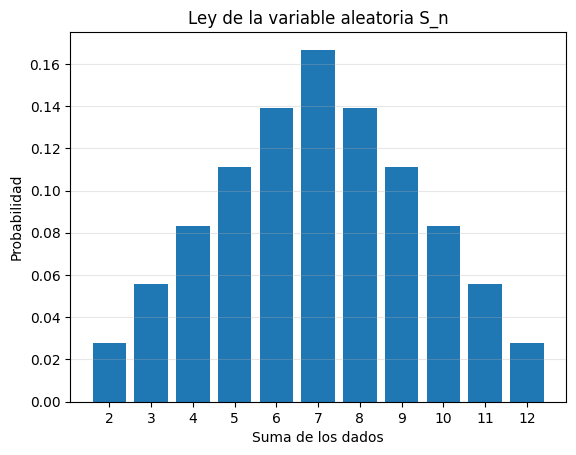

In [75]:
plt.bar(Ley_Sn.index, Ley_Sn.values)
plt.grid(alpha=0.3, axis='y')
plt.xlabel('Suma de los dados')
plt.ylabel('Probabilidad')
plt.title('Ley de la variable aleatoria S_n')
plt.xticks(Ley_Sn.index)
plt.show()